In [1]:
import os
import numpy as np
import pandas as pd

from funciones_metricas import (
    matriz_metricas,
    comunas_inestables,
    estabilidad_comuna,
    comunas_inestables_nombres
)


In [2]:

ruta_resultados = r"C:\Tesis\Códigos\resultados"
ruta_comunas = r"C:\Tesis\Códigos\DataChile\comunas.xlsx"

comunas_df = pd.read_excel(ruta_comunas)
comunas_df["comuna"] = comunas_df["comuna"].str.lower().str.strip()

poblacion = dict(zip(comunas_df["comuna"], comunas_df["poblacion2017"]))

In [3]:
def df_a_labels(df):
    df = df[df["x"] == 1].copy()

    df["i"] = df["i"].str.lower().str.strip()
    df["j"] = df["j"].str.lower().str.strip()

    asignacion = dict(zip(df["i"], df["j"]))

    centros = sorted(set(asignacion.values()))
    mapa_centros = {c: idx for idx, c in enumerate(centros)}

    comunas = sorted(asignacion.keys())
    labels = [mapa_centros[asignacion[i]] for i in comunas]

    return labels, comunas

In [4]:
def detectar_tipo_y_metodo(carpeta):
    partes = carpeta.split("_")

    tipo = None
    metodo = None

    for p in partes:
        if p in ["CL", "SL"]:
            tipo = p

    nombre_lower = carpeta.lower()

    if "sys" in nombre_lower:
        metodo = "sys"
    elif "pivotal" in nombre_lower or "piv" in nombre_lower:
        metodo = "pivotal"
    elif "samp" in nombre_lower:
        metodo = "sampford"

    return tipo, metodo

In [5]:
def cargar_labels_desde_resultados(ruta_resultados, tipo_filtrar=None, metodo_filtrar=None):
    mapas = {}
    comunas_base = None
    asignaciones = {}

    for carpeta in sorted(os.listdir(ruta_resultados)):
        path_carpeta = os.path.join(ruta_resultados, carpeta)

        if not os.path.isdir(path_carpeta):
            continue

        tipo, metodo = detectar_tipo_y_metodo(carpeta)

        if tipo_filtrar is not None and tipo != tipo_filtrar:
            continue

        if metodo_filtrar is not None and metodo != metodo_filtrar:
            continue

        for sub in os.listdir(path_carpeta):
            path_sub = os.path.join(path_carpeta, sub)

            if not os.path.isdir(path_sub):
                continue

            archivos = os.listdir(path_sub)
            archivo_asig = [a for a in archivos if "asignaciones" in a]

            if len(archivo_asig) == 0:
                continue

            path_archivo = os.path.join(path_sub, archivo_asig[0])

            df = pd.read_csv(path_archivo)
            labels, comunas = df_a_labels(df)

            nombre_mapa = f"{carpeta}_{sub}"

            if comunas_base is None:
                comunas_base = comunas
            elif comunas != comunas_base:
                raise ValueError(f"Las comunas no coinciden en {nombre_mapa}")

            mapas[nombre_mapa] = labels
            asignaciones[nombre_mapa] = df

    return mapas, comunas_base, asignaciones

In [6]:
def resumen_matriz(M):
    valores = M.values
    valores = valores[~np.eye(valores.shape[0], dtype=bool)]

    return {
        "mean": valores.mean(),
        "std": valores.std(),
        "min": valores.min(),
        "max": valores.max()
    }

In [7]:
def metricas_poblacion_distritos(df):
    df = df[df["x"] == 1].copy()

    df["i"] = df["i"].str.lower().str.strip()
    df["j"] = df["j"].str.lower().str.strip()

    df["poblacion"] = df["i"].map(poblacion)

    if df["poblacion"].isna().any():
        faltantes = sorted(df[df["poblacion"].isna()]["i"].unique())
        raise ValueError(f"Comunas sin población: {faltantes}")

    pop_distritos = df.groupby("j")["poblacion"].sum()

    return {
        "pop_distrito_mean": pop_distritos.mean(),
        "pop_distrito_std": pop_distritos.std(),
        "pop_distrito_min": pop_distritos.min(),
        "pop_distrito_max": pop_distritos.max(),
        "pop_distrito_rango": pop_distritos.max() - pop_distritos.min(),
        "pop_distrito_cv": pop_distritos.std() / pop_distritos.mean(),
        "pop_distrito_mediana": pop_distritos.median()
    }

In [7]:
def analizar_grupo(tipo, metodo=None):
    mapas, comunas, asignaciones = cargar_labels_desde_resultados(
        ruta_resultados,
        tipo_filtrar=tipo,
        metodo_filtrar=metodo
    )

    if len(mapas) < 2:
        return None

    matriz_ari = matriz_metricas(mapas, metrica="ari")
    matriz_nmi = matriz_metricas(mapas, metrica="nmi")
    matriz_vi  = matriz_metricas(mapas, metrica="vi")

    resumen_ari = resumen_matriz(matriz_ari)
    resumen_nmi = resumen_matriz(matriz_nmi)
    resumen_vi  = resumen_matriz(matriz_vi)

    inestables = comunas_inestables(mapas)
    estabilidades = estabilidad_comuna(mapas)

    pop_metricas = []
    for nombre, df in asignaciones.items():
        m = metricas_poblacion_distritos(df)
        m["mapa"] = nombre
        pop_metricas.append(m)

    tabla_pop = pd.DataFrame(pop_metricas)

    resumen = {
        "tipo": tipo,
        "metodo": metodo if metodo is not None else "todos",
        "n_mapas": len(mapas),

        "ari_mean": resumen_ari["mean"],
        "ari_std": resumen_ari["std"],

        "nmi_mean": resumen_nmi["mean"],
        "nmi_std": resumen_nmi["std"],

        "vi_mean": resumen_vi["mean"],
        "vi_std": resumen_vi["std"],

        "n_comunas_inestables": len(inestables),
        "n_comunas_estables": sum(e == 1.0 for e in estabilidades),
        "estabilidad_promedio": np.mean(estabilidades),

        "pop_mean_promedio": tabla_pop["pop_distrito_mean"].mean(),
        "pop_std_promedio": tabla_pop["pop_distrito_std"].mean(),
        "pop_cv_promedio": tabla_pop["pop_distrito_cv"].mean(),
        "pop_rango_promedio": tabla_pop["pop_distrito_rango"].mean(),
    }

    return {
        "resumen": resumen,
        "tabla_poblacion": tabla_pop,
        "matriz_ari": matriz_ari,
        "matriz_nmi": matriz_nmi,
        "matriz_vi": matriz_vi
    }

In [8]:
resultados = []
analisis = {}

for tipo in ["CL", "SL"]:
    res = analizar_grupo(tipo)

    if res is not None:
        analisis[tipo] = res
        resultados.append(res["resumen"])

tabla_resumen = pd.DataFrame(resultados)
display(tabla_resumen)

,tipo,metodo,n_mapas,ari_mean,ari_std,nmi_mean,nmi_std,vi_mean,vi_std,n_comunas_inestables,n_comunas_estables,estabilidad_promedio,pop_mean_promedio,pop_std_promedio,pop_cv_promedio,pop_rango_promedio
0,CL,todos,300,0.808532,0.047969,0.909229,0.014268,0.575817,0.091635,325,21,0.321696,625678.268357,349805.507259,0.559082,1.051074e+06
1,SL,todos,300,0.360478,0.046605,0.686697,0.020130,1.908008,0.119217,346,0,0.093112,625678.268357,375684.100733,0.600443,1.057274e+06


In [9]:
salida_excel = "metricas_resumen_CL_SL.xlsx"

with pd.ExcelWriter(salida_excel, engine="openpyxl") as writer:

    tabla_resumen.to_excel(writer, sheet_name="resumen_CL_SL", index=False)

    for tipo, res in analisis.items():
        res["tabla_poblacion"].to_excel(writer, sheet_name=f"poblacion_{tipo}", index=False)

        pd.DataFrame(res["matriz_ari"]).to_excel(writer, sheet_name=f"ARI_{tipo}")
        pd.DataFrame(res["matriz_nmi"]).to_excel(writer, sheet_name=f"NMI_{tipo}")
        pd.DataFrame(res["matriz_vi"]).to_excel(writer, sheet_name=f"VI_{tipo}")

In [5]:
excel_metricas = "metricas_resumen_CL_SL.xlsx"

df_cl = pd.read_excel(excel_metricas, sheet_name="poblacion_CL")
df_sl = pd.read_excel(excel_metricas, sheet_name="poblacion_SL")

In [6]:
def agregar_metodo(df):
    df = df.copy()
    nombre = df["mapa"].str.lower()

    df["metodo"] = None
    df.loc[nombre.str.contains("sys|systematic"), "metodo"] = "sys"
    df.loc[nombre.str.contains("pivotal|piv"), "metodo"] = "pivotal"
    df.loc[nombre.str.contains("samp"), "metodo"] = "sampford"

    return df

df_cl = agregar_metodo(df_cl)
df_sl = agregar_metodo(df_sl)

In [12]:
def resumen_metodo_excel(df, tipo, metodo):
    aux = df[df["metodo"] == metodo].copy()

    return pd.DataFrame([{
        "tipo": tipo,
        "metodo": metodo,
        "n_mapas": len(aux),

        "pop_mean_promedio": aux["pop_distrito_mean"].mean(),
        "pop_std_promedio": aux["pop_distrito_std"].mean(),
        "pop_cv_promedio": aux["pop_distrito_cv"].mean(),
        "pop_rango_promedio": aux["pop_distrito_rango"].mean(),
    }])

In [13]:
tabla_cl_metodos = pd.concat([
    resumen_metodo_excel(df_cl, "CL", m)
    for m in ["sys", "pivotal", "sampford"]
])

display(tabla_cl_metodos)

,tipo,metodo,n_mapas,pop_mean_promedio,pop_std_promedio,pop_cv_promedio,pop_rango_promedio
0,CL,sys,100,625678.268357,351997.863669,0.562586,1.051039e+06
0,CL,pivotal,100,625678.268357,346195.287954,0.553312,1.050991e+06
0,CL,sampford,100,625678.268357,351223.370153,0.561348,1.051191e+06


In [14]:
tabla_cl_metodos = pd.concat([
    resumen_metodo_excel(df_sl, "SL", m)
    for m in ["sys", "pivotal", "sampford"]
])

display(tabla_cl_metodos)

,tipo,metodo,n_mapas,pop_mean_promedio,pop_std_promedio,pop_cv_promedio,pop_rango_promedio
0,SL,sys,100,625678.268357,375028.863128,0.599396,1.055962e+06
0,SL,pivotal,100,625678.268357,376587.501491,0.601887,1.057325e+06
0,SL,sampford,100,625678.268357,375435.937581,0.600046,1.058535e+06


In [3]:
def mejores_mapas_poblacion(df, tipo, top=10):
    df = agregar_metodo(df)

    cols = [
        "mapa",
        "metodo",
        "pop_distrito_mean",
        "pop_distrito_std",
        "pop_distrito_cv",
        "pop_distrito_rango",
        "pop_distrito_min",
        "pop_distrito_max",
    ]

    mejores = (
        df[cols]
        .sort_values(["pop_distrito_cv", "pop_distrito_std", "pop_distrito_rango"])
        .head(top)
        .copy()
    )

    mejores.insert(0, "tipo", tipo)

    return mejores

In [16]:
mejores_cl = mejores_mapas_poblacion(df_cl, "CL", top=10)
mejores_sl = mejores_mapas_poblacion(df_sl, "SL", top=10)

display(mejores_cl)
display(mejores_sl)

,tipo,mapa,metodo,pop_distrito_mean,pop_distrito_std,pop_distrito_cv,pop_distrito_rango,pop_distrito_min,pop_distrito_max
227,CL,resultados_CL_samp_epsilon_0.87_t_028,sampford,625678.268357,287178.957439,0.458988,1035885.157,101316.843,1137202.00
42,CL,resultados_CL_PIVOTAL_epsilon_0.87_t_043,pivotal,625678.268357,297707.104527,0.475815,1010494.157,101316.843,1111811.00
73,CL,resultados_CL_PIVOTAL_epsilon_0.87_t_074,pivotal,625678.268357,300342.375497,0.480027,1018846.907,101316.843,1120163.75
87,CL,resultados_CL_PIVOTAL_epsilon_0.87_t_088,pivotal,625678.268357,305773.566914,0.488707,996766.000,99492.000,1096258.00
243,CL,resultados_CL_samp_epsilon_0.87_t_044,sampford,625678.268357,306604.079570,0.490035,1064474.157,101316.843,1165791.00
216,CL,resultados_CL_samp_epsilon_0.87_t_017,sampford,625678.268357,311755.389436,0.498268,998130.000,100080.000,1098210.00
114,CL,resultados_CL_SYS_epsilon_0.87_t_015,sys,625678.268357,313371.024802,0.500850,1052463.157,101316.843,1153780.00
280,CL,resultados_CL_samp_epsilon_0.87_t_081,sampford,625678.268357,316182.100389,0.505343,1045601.157,101316.843,1146918.00
43,CL,resultados_CL_PIVOTAL_epsilon_0.87_t_044,pivotal,625678.268357,316826.499726,0.506373,1035885.157,101316.843,1137202.00
72,CL,resultados_CL_PIVOTAL_epsilon_0.87_t_073,pivotal,625678.268357,317279.236692,0.507096,1067624.157,101316.843,1168941.00


,tipo,mapa,metodo,pop_distrito_mean,pop_distrito_std,pop_distrito_cv,pop_distrito_rango,pop_distrito_min,pop_distrito_max
46,SL,resultados_SL_piv_epsilon_0.87_t_047,pivotal,625678.268357,283448.506221,0.453026,980355.000,126319.0,1106674.000
93,SL,resultados_SL_piv_epsilon_0.87_t_094,pivotal,625678.268357,284858.607006,0.455280,1026858.000,110603.0,1137461.000
58,SL,resultados_SL_piv_epsilon_0.87_t_059,pivotal,625678.268357,294643.328952,0.470918,1000976.000,118696.0,1119672.000
112,SL,resultados_SL_samp_epsilon_0.87_t_013,sampford,625678.268357,297122.822725,0.474881,1051128.000,82629.0,1133757.000
50,SL,resultados_SL_piv_epsilon_0.87_t_051,pivotal,625678.268357,297819.658168,0.475995,932742.000,221237.0,1153979.000
98,SL,resultados_SL_piv_epsilon_0.87_t_099,pivotal,625678.268357,299209.347630,0.478216,943050.000,216072.0,1159122.000
82,SL,resultados_SL_piv_epsilon_0.87_t_083,pivotal,625678.268357,300662.274216,0.480538,1056998.921,103739.0,1160737.921
267,SL,resultados_SL_sys_epsilon_0.87_t_068,sys,625678.268357,300863.665198,0.480860,972531.000,191629.0,1164160.000
200,SL,resultados_SL_sys_epsilon_0.87_t_001,sys,625678.268357,303902.782999,0.485717,1022579.000,146207.0,1168786.000
215,SL,resultados_SL_sys_epsilon_0.87_t_016,sys,625678.268357,306183.257212,0.489362,963030.000,141567.0,1104597.000


In [17]:
def mejores_por_metodo(df, tipo, top=5):
    df = agregar_metodo(df)

    return (
        df.sort_values(["metodo", "pop_distrito_cv", "pop_distrito_std"])
          .groupby("metodo")
          .head(top)
          .reset_index(drop=True)
    )

display(mejores_por_metodo(df_cl, "CL", top=5))
display(mejores_por_metodo(df_sl, "SL", top=5))

,pop_distrito_mean,pop_distrito_std,pop_distrito_min,pop_distrito_max,pop_distrito_rango,pop_distrito_cv,pop_distrito_mediana,mapa,metodo
0,625678.268357,297707.104527,101316.843,1111811.00,1010494.157,0.475815,650111.500,resultados_CL_PIVOTAL_epsilon_0.87_t_043,pivotal
1,625678.268357,300342.375497,101316.843,1120163.75,1018846.907,0.480027,673571.500,resultados_CL_PIVOTAL_epsilon_0.87_t_074,pivotal
2,625678.268357,305773.566914,99492.000,1096258.00,996766.000,0.488707,622459.500,resultados_CL_PIVOTAL_epsilon_0.87_t_088,pivotal
3,625678.268357,316826.499726,101316.843,1137202.00,1035885.157,0.506373,722322.000,resultados_CL_PIVOTAL_epsilon_0.87_t_044,pivotal
4,625678.268357,317279.236692,101316.843,1168941.00,1067624.157,0.507096,673015.875,resultados_CL_PIVOTAL_epsilon_0.87_t_073,pivotal
5,625678.268357,287178.957439,101316.843,1137202.00,1035885.157,0.458988,728144.000,resultados_CL_samp_epsilon_0.87_t_028,sampford
6,625678.268357,306604.079570,101316.843,1165791.00,1064474.157,0.490035,604626.000,resultados_CL_samp_epsilon_0.87_t_044,sampford
7,625678.268357,311755.389436,100080.000,1098210.00,998130.000,0.498268,729957.000,resultados_CL_samp_epsilon_0.87_t_017,sampford
8,625678.268357,316182.100389,101316.843,1146918.00,1045601.157,0.505343,623210.500,resultados_CL_samp_epsilon_0.87_t_081,sampford
9,625678.268357,319644.940731,101316.843,1157317.00,1056000.157,0.510877,698061.500,resultados_CL_samp_epsilon_0.87_t_034,sampford


,pop_distrito_mean,pop_distrito_std,pop_distrito_min,pop_distrito_max,pop_distrito_rango,pop_distrito_cv,pop_distrito_mediana,mapa,metodo
0,625678.268357,283448.506221,126319.0,1106674.0,980355.0,0.453026,613425.5000,resultados_SL_piv_epsilon_0.87_t_047,pivotal
1,625678.268357,284858.607006,110603.0,1137461.0,1026858.0,0.455280,692133.5000,resultados_SL_piv_epsilon_0.87_t_094,pivotal
2,625678.268357,294643.328952,118696.0,1119672.0,1000976.0,0.470918,659808.5000,resultados_SL_piv_epsilon_0.87_t_059,pivotal
3,625678.268357,297819.658168,221237.0,1153979.0,932742.0,0.475995,583961.0000,resultados_SL_piv_epsilon_0.87_t_051,pivotal
4,625678.268357,299209.347630,216072.0,1159122.0,943050.0,0.478216,575370.5000,resultados_SL_piv_epsilon_0.87_t_099,pivotal
5,625678.268357,297122.822725,82629.0,1133757.0,1051128.0,0.474881,630789.5000,resultados_SL_samp_epsilon_0.87_t_013,sampford
6,625678.268357,313959.406910,87320.0,1167625.0,1080305.0,0.501790,627662.5000,resultados_SL_samp_epsilon_0.87_t_082,sampford
7,625678.268357,316850.054711,138529.0,1168786.0,1030257.0,0.506411,638142.4215,resultados_SL_samp_epsilon_0.87_t_063,sampford
8,625678.268357,320399.644310,108375.0,1121624.0,1013249.0,0.512084,566710.4605,resultados_SL_samp_epsilon_0.87_t_042,sampford
9,625678.268357,323196.155290,103908.0,1169109.0,1065201.0,0.516553,607965.0000,resultados_SL_samp_epsilon_0.87_t_002,sampford


In [18]:
with pd.ExcelWriter("mejores_mapas_poblacion.xlsx", engine="openpyxl") as writer:
    mejores_cl.to_excel(writer, sheet_name="mejores_CL", index=False)
    mejores_sl.to_excel(writer, sheet_name="mejores_SL", index=False)

    mejores_por_metodo(df_cl, "CL", top=5).to_excel(
        writer, sheet_name="mejores_metodo_CL", index=False
    )

    mejores_por_metodo(df_sl, "SL", top=5).to_excel(
        writer, sheet_name="mejores_metodo_SL", index=False
    )

In [19]:
def mejores_metricas(tabla_metricas, top=10):
    df = tabla_metricas.copy()

    df["score"] = (
        df["ari_mean"]
        + df["nmi_mean"]
        - df["vi_mean"]
    )

    mejores = (
        df.sort_values(
            ["score", "ari_mean", "nmi_mean", "vi_mean"],
            ascending=[False, False, False, True]
        )
        .head(top)
        .copy()
    )

    return mejores

In [20]:
excel_metricas = "metricas_resumen_CL_SL.xlsx"

ari_cl = pd.read_excel(excel_metricas, sheet_name="ARI_CL", index_col=0)
nmi_cl = pd.read_excel(excel_metricas, sheet_name="NMI_CL", index_col=0)
vi_cl  = pd.read_excel(excel_metricas, sheet_name="VI_CL", index_col=0)

ari_sl = pd.read_excel(excel_metricas, sheet_name="ARI_SL", index_col=0)
nmi_sl = pd.read_excel(excel_metricas, sheet_name="NMI_SL", index_col=0)
vi_sl  = pd.read_excel(excel_metricas, sheet_name="VI_SL", index_col=0)

In [21]:
def resumen_matriz_por_metodo(M, metodo):
    nombres = pd.Series(M.index.astype(str), index=M.index)
    nombres_low = nombres.str.lower()

    if metodo == "sys":
        patron = "sys|systematic"
    elif metodo == "pivotal":
        patron = "pivotal|piv"
    elif metodo in ["samp", "sampford"]:
        patron = "samp"
    else:
        patron = metodo

    idx = nombres[nombres_low.str.contains(patron, regex=True)].index
    sub = M.loc[idx, idx]

    if sub.shape[0] < 2:
        return {
            "mean": np.nan,
            "std": np.nan,
            "min": np.nan,
            "max": np.nan,
            "n": sub.shape[0]
        }

    valores = sub.values
    valores = valores[~np.eye(valores.shape[0], dtype=bool)]

    return {
        "mean": valores.mean(),
        "std": valores.std(),
        "min": valores.min(),
        "max": valores.max(),
        "n": sub.shape[0]
    }


def resumen_metricas_tipo(ari, nmi, vi, tipo):
    metodos = ["sys", "pivotal", "samp"]

    filas = []

    for m in metodos:
        r_ari = resumen_matriz_por_metodo(ari, m)
        r_nmi = resumen_matriz_por_metodo(nmi, m)
        r_vi  = resumen_matriz_por_metodo(vi, m)

        filas.append({
            "tipo": tipo,
            "metodo": m,

            "ari_mean": r_ari["mean"],
            "ari_std": r_ari["std"],
            "ari_min": r_ari["min"],
            "ari_max": r_ari["max"],

            "nmi_mean": r_nmi["mean"],
            "nmi_std": r_nmi["std"],
            "nmi_min": r_nmi["min"],
            "nmi_max": r_nmi["max"],

            "vi_mean": r_vi["mean"],
            "vi_std": r_vi["std"],
            "vi_min": r_vi["min"],
            "vi_max": r_vi["max"],

            "n_mapas": r_ari["n"]
        })

    return pd.DataFrame(filas)

In [22]:
tabla_cl_metricas = resumen_metricas_tipo(ari_cl, nmi_cl, vi_cl, "CL")
tabla_sl_metricas = resumen_metricas_tipo(ari_sl, nmi_sl, vi_sl, "SL")

display(tabla_cl_metricas)
display(tabla_sl_metricas)

,tipo,metodo,ari_mean,ari_std,ari_min,ari_max,nmi_mean,nmi_std,nmi_min,nmi_max,vi_mean,vi_std,vi_min,vi_max,n_mapas
0,CL,sys,0.813539,0.045346,0.661470,0.977014,0.910538,0.013848,0.865259,0.972171,0.567381,0.088663,0.174120,0.861472,100
1,CL,pivotal,0.807981,0.048751,0.661833,0.970153,0.909232,0.014966,0.861494,0.968535,0.576187,0.096255,0.198048,0.886514,100
2,CL,samp,0.804295,0.049274,0.661557,0.965186,0.907971,0.014191,0.868557,0.962546,0.583553,0.091312,0.235989,0.839828,100


,tipo,metodo,ari_mean,ari_std,ari_min,ari_max,nmi_mean,nmi_std,nmi_min,nmi_max,vi_mean,vi_std,vi_min,vi_max,n_mapas
0,SL,sys,0.364574,0.044615,0.231815,0.614339,0.688190,0.018796,0.623033,0.771855,1.903127,0.113453,1.414319,2.305215,100
1,SL,pivotal,0.357837,0.049375,0.220643,0.638799,0.684935,0.021055,0.608426,0.766169,1.915744,0.123792,1.450414,2.336077,100
2,SL,samp,0.360297,0.045866,0.240380,0.590169,0.687500,0.019975,0.618391,0.791122,1.901979,0.118743,1.260389,2.302150,100


In [23]:
def metricas_entre_metodos(M):
    nombres = pd.Series(M.index.astype(str), index=M.index)
    nombres_low = nombres.str.lower()

    def get_metodo(n):
        if "sys" in n or "systematic" in n:
            return "sys"
        elif "piv" in n:
            return "pivotal"
        elif "samp" in n:
            return "samp"
        return "otro"

    metodos = nombres_low.apply(get_metodo)

    resultados = []

    lista_metodos = ["sys", "pivotal", "samp"]

    for i in range(len(lista_metodos)):
        for j in range(i+1, len(lista_metodos)):
            m1 = lista_metodos[i]
            m2 = lista_metodos[j]

            idx1 = metodos[metodos == m1].index
            idx2 = metodos[metodos == m2].index

            sub = M.loc[idx1, idx2]

            valores = sub.values.flatten()

            resultados.append({
                "metodo_1": m1,
                "metodo_2": m2,
                "mean": np.mean(valores),
                "std": np.std(valores),
                "min": np.min(valores),
                "max": np.max(valores),
                "n_pares": len(valores)
            })

    return pd.DataFrame(resultados)

In [24]:
entre_cl_ari = metricas_entre_metodos(ari_cl)
entre_cl_nmi = metricas_entre_metodos(nmi_cl)
entre_cl_vi  = metricas_entre_metodos(vi_cl)

display(entre_cl_ari)
display(entre_cl_nmi)
display(entre_cl_vi)

,metodo_1,metodo_2,mean,std,min,max,n_pares
0,sys,pivotal,0.810991,0.047336,0.660593,0.972941,10000
1,sys,samp,0.808928,0.047620,0.658461,0.959806,10000
2,pivotal,samp,0.805567,0.048777,0.647699,0.972685,10000


,metodo_1,metodo_2,mean,std,min,max,n_pares
0,sys,pivotal,0.909981,0.014502,0.866331,0.975605,10000
1,sys,samp,0.909241,0.013841,0.869627,0.965764,10000
2,pivotal,samp,0.908438,0.014242,0.866412,0.971464,10000


,metodo_1,metodo_2,mean,std,min,max,n_pares
0,sys,pivotal,0.571165,0.093025,0.154937,0.859926,10000
1,sys,samp,0.575555,0.088887,0.217848,0.836917,10000
2,pivotal,samp,0.580895,0.091587,0.178913,0.857327,10000


In [25]:
entre_sl_ari = metricas_entre_metodos(ari_sl)
entre_sl_nmi = metricas_entre_metodos(nmi_sl)
entre_sl_vi  = metricas_entre_metodos(vi_sl)

In [26]:
display(entre_sl_ari)
display(entre_sl_nmi)
display(entre_sl_vi)

,metodo_1,metodo_2,mean,std,min,max,n_pares
0,sys,pivotal,0.360122,0.047256,0.216460,0.631127,10000
1,sys,samp,0.361868,0.045037,0.209499,0.594428,10000
2,pivotal,samp,0.358814,0.047224,0.227764,0.636253,10000


,metodo_1,metodo_2,mean,std,min,max,n_pares
0,sys,pivotal,0.686044,0.020060,0.603502,0.765042,10000
1,sys,samp,0.687644,0.019622,0.610701,0.774769,10000
2,pivotal,samp,0.686139,0.020824,0.612574,0.771679,10000


,metodo_1,metodo_2,mean,std,min,max,n_pares
0,sys,pivotal,1.912579,0.118837,1.412478,2.366510,10000
1,sys,samp,1.903718,0.116566,1.355869,2.366113,10000
2,pivotal,samp,1.909300,0.122463,1.357949,2.295953,10000


In [27]:
def resumen_poblacion_por_metodo(df, tipo):
    df = agregar_metodo(df)

    return (
        df.groupby("metodo")
        .agg({
            "pop_distrito_cv": "mean",
            "pop_distrito_std": "mean",
            "pop_distrito_rango": "mean"
        })
        .reset_index()
        .assign(tipo=tipo)
    )

In [28]:
tabla_pop_cl = resumen_poblacion_por_metodo(df_cl, "CL")
tabla_pop_sl = resumen_poblacion_por_metodo(df_sl, "SL")

tabla_pop_cl["metodo"] = tabla_pop_cl["metodo"].replace({"sampford": "samp"})
tabla_pop_sl["metodo"] = tabla_pop_sl["metodo"].replace({"sampford": "samp"})

In [29]:
def diversidad_promedio(df_metricas, tipo):
    a = df_metricas[["metodo_1", "mean"]].rename(columns={"metodo_1": "metodo"})
    b = df_metricas[["metodo_2", "mean"]].rename(columns={"metodo_2": "metodo"})

    return (
        pd.concat([a, b])
        .groupby("metodo")["mean"]
        .mean()
        .reset_index()
        .rename(columns={"mean": "ari_inter"})
        .assign(tipo=tipo)
    )

In [30]:
div_cl = diversidad_promedio(entre_cl_ari, "CL")
div_sl = diversidad_promedio(entre_sl_ari, "SL")

tabla_final_cl = tabla_pop_cl.merge(div_cl, on=["metodo", "tipo"])
tabla_final_sl = tabla_pop_sl.merge(div_sl, on=["metodo", "tipo"])

tabla_final = pd.concat([tabla_final_cl, tabla_final_sl]).reset_index(drop=True)

tabla_final_fmt = tabla_final.copy()

cols_pob = ["pop_distrito_std", "pop_distrito_rango"]

for c in cols_pob:
    tabla_final_fmt[c] = tabla_final_fmt[c].round(0).astype(int)

tabla_final_fmt["pop_distrito_cv"] = tabla_final_fmt["pop_distrito_cv"].round(4)
tabla_final_fmt["ari_inter"] = tabla_final_fmt["ari_inter"].round(4)

display(
    tabla_final_fmt.style.format({
        "pop_distrito_std": "{:,.0f}",
        "pop_distrito_rango": "{:,.0f}",
        "pop_distrito_cv": "{:.4f}",
        "ari_inter": "{:.4f}",
    })
)

,metodo,pop_distrito_cv,pop_distrito_std,pop_distrito_rango,tipo,ari_inter
0,pivotal,0.5533,"346,195","1,050,991",CL,0.8083
1,samp,0.5613,"351,223","1,051,191",CL,0.8072
2,sys,0.5626,"351,998","1,051,039",CL,0.8100
3,pivotal,0.6019,"376,588","1,057,325",SL,0.3595
4,samp,0.6000,"375,436","1,058,535",SL,0.3603
5,sys,0.5994,"375,029","1,055,962",SL,0.3610


## Conclusiones

### Modelo CL (con límite)
- **Diversidad entre métodos**: alta similitud (`ARI ≈ 0.81`)
- **Equilibrio poblacional**:
  - Mejor: **pivotal** (`CV = 0.5533`)
  - Intermedio: samp
  - Peor: sys

**Conclusión**:  
El método de sampleo **no afecta la estructura de los mapas**, pero sí influye levemente en el equilibrio poblacional.  
Podemos decir que el mejor es **pivotal**.

---

### Modelo SL (sin límite)
- **Diversidad entre métodos**: baja similitud (`ARI ≈ 0.36`)
- **Equilibrio poblacional**:
  - Mejor: **sys** (`CV = 0.5887`)
  - Luego: samp $\approx$ pivotal

**Conclusión**:  
El método de sampleo **sí afecta significativamente los resultados**.  
Además, **sys logra mejor balance poblacional**.

---

### Conclusión global

- **CL**: el método es prácticamente irrelevante (mapas similares)
- **SL**: el método afecta claramente (mapas distintos)

# Veamos adyacencias

In [5]:
# cargar adyacencias
with open("DataChile/adyacencia_comunas.txt", "r") as f:
    dict_ady = eval(f.read())


def metrica_adyacencia_externa(df_asig):
    df = df_asig[df_asig["x"] == 1].copy()

    df["i"] = df["i"].str.lower().str.strip()
    df["j"] = df["j"].str.lower().str.strip()

    # mapa comuna -> distrito
    asignacion = dict(zip(df["i"], df["j"]))

    conteo = 0

    for comuna, distrito in asignacion.items():
        vecinos = dict_ady.get(comuna, [])

        for v in vecinos:
            v = v.lower().strip()

            if v in asignacion:
                if asignacion[v] != distrito:
                    conteo += 1

    return conteo

In [6]:
def calcular_metrica_adyacencia(df):
    resultados = []

    for _, row in df.iterrows():
        mapa = row["mapa"]

        # reconstruir ruta
        partes = mapa.split("_t_")
        carpeta = partes[0]
        t = partes[1]

        ruta = f"resultados/{carpeta}/t_{t}/t_{t}_asignaciones.csv"

        df_asig = pd.read_csv(ruta)

        valor = metrica_adyacencia_externa(df_asig)

        resultados.append({
            "mapa": mapa,
            "ady_externa": valor
        })

    return pd.DataFrame(resultados)

In [7]:
ady_cl = calcular_metrica_adyacencia(df_cl)


In [39]:
display(ady_cl.sort_values("ady_externa", ascending=False).head(10))


,mapa,ady_externa
295,resultados_CL_samp_epsilon_0.87_t_096,535
111,resultados_CL_SYS_epsilon_0.87_t_012,531
271,resultados_CL_samp_epsilon_0.87_t_072,529
141,resultados_CL_SYS_epsilon_0.87_t_042,528
167,resultados_CL_SYS_epsilon_0.87_t_068,528
197,resultados_CL_SYS_epsilon_0.87_t_098,527
98,resultados_CL_PIVOTAL_epsilon_0.87_t_099,523
270,resultados_CL_samp_epsilon_0.87_t_071,523
51,resultados_CL_PIVOTAL_epsilon_0.87_t_052,522
272,resultados_CL_samp_epsilon_0.87_t_073,522


In [37]:
display(ady_cl.sort_values("ady_externa").head(10))

,mapa,ady_externa
293,resultados_CL_samp_epsilon_0.87_t_094,440
61,resultados_CL_PIVOTAL_epsilon_0.87_t_062,441
119,resultados_CL_SYS_epsilon_0.87_t_020,446
188,resultados_CL_SYS_epsilon_0.87_t_089,448
46,resultados_CL_PIVOTAL_epsilon_0.87_t_047,450
205,resultados_CL_samp_epsilon_0.87_t_006,451
24,resultados_CL_PIVOTAL_epsilon_0.87_t_025,453
276,resultados_CL_samp_epsilon_0.87_t_077,453
87,resultados_CL_PIVOTAL_epsilon_0.87_t_088,454
256,resultados_CL_samp_epsilon_0.87_t_057,456


In [38]:
display(
    df_cl.merge(ady_cl, on="mapa")
         .sort_values("ady_externa")
         [["mapa", "metodo", "ady_externa"]]
         .head(10)
)

,mapa,metodo,ady_externa
293,resultados_CL_samp_epsilon_0.87_t_094,sampford,440
61,resultados_CL_PIVOTAL_epsilon_0.87_t_062,pivotal,441
119,resultados_CL_SYS_epsilon_0.87_t_020,sys,446
188,resultados_CL_SYS_epsilon_0.87_t_089,sys,448
46,resultados_CL_PIVOTAL_epsilon_0.87_t_047,pivotal,450
205,resultados_CL_samp_epsilon_0.87_t_006,sampford,451
24,resultados_CL_PIVOTAL_epsilon_0.87_t_025,pivotal,453
276,resultados_CL_samp_epsilon_0.87_t_077,sampford,453
87,resultados_CL_PIVOTAL_epsilon_0.87_t_088,pivotal,454
256,resultados_CL_samp_epsilon_0.87_t_057,sampford,456


In [10]:
ady_sl = calcular_metrica_adyacencia(df_sl)


In [11]:
display(
    df_sl.merge(ady_sl, on="mapa")
         .sort_values("ady_externa")
         [["mapa", "metodo", "ady_externa"]]
         .head(10)
)

,mapa,metodo,ady_externa
50,resultados_SL_piv_epsilon_0.87_t_051,pivotal,448
221,resultados_SL_sys_epsilon_0.87_t_022,sys,482
93,resultados_SL_piv_epsilon_0.87_t_094,pivotal,494
108,resultados_SL_samp_epsilon_0.87_t_009,sampford,496
293,resultados_SL_sys_epsilon_0.87_t_094,sys,504
84,resultados_SL_piv_epsilon_0.87_t_085,pivotal,507
237,resultados_SL_sys_epsilon_0.87_t_038,sys,509
35,resultados_SL_piv_epsilon_0.87_t_036,pivotal,510
103,resultados_SL_samp_epsilon_0.87_t_004,sampford,511
98,resultados_SL_piv_epsilon_0.87_t_099,pivotal,514


In [43]:
display(ady_sl.sort_values("ady_externa", ascending=False).head(10))

,mapa,ady_externa
286,resultados_SL_sys_epsilon_0.87_t_087,696
250,resultados_SL_sys_epsilon_0.87_t_051,693
136,resultados_SL_samp_epsilon_0.87_t_037,692
257,resultados_SL_sys_epsilon_0.87_t_058,686
209,resultados_SL_sys_epsilon_0.87_t_010,684
208,resultados_SL_sys_epsilon_0.87_t_009,683
214,resultados_SL_sys_epsilon_0.87_t_015,676
71,resultados_SL_piv_epsilon_0.87_t_072,676
78,resultados_SL_piv_epsilon_0.87_t_079,675
27,resultados_SL_piv_epsilon_0.87_t_028,673


In [8]:
def resumen_adyacencias(ady_df, tipo):
    x = ady_df["ady_externa"]

    return pd.DataFrame([{
        "tipo": tipo,
        "mean": x.mean(),
        "std": x.std(),
        "min": x.min(),
        "25%": x.quantile(0.25),
        "median": x.median(),
        "75%": x.quantile(0.75),
        "max": x.max(),
        "n": len(x)
    }])

In [12]:
resumen_ady_cl = resumen_adyacencias(ady_cl, "CL")
resumen_ady_sl = resumen_adyacencias(ady_sl, "SL")

tabla_ady = pd.concat([resumen_ady_cl, resumen_ady_sl], ignore_index=True)

display(tabla_ady)

,tipo,mean,std,min,25%,median,75%,max,n
0,CL,487.793333,18.247755,440,475.0,488.0,499.25,535,300
1,SL,600.663333,40.494890,448,575.0,600.0,628.00,696,300


In [13]:
def resumen_ady_por_metodo(ady_df, df_base, tipo):
    df = df_base[["mapa", "metodo"]].merge(ady_df, on="mapa")

    return (
        df.groupby("metodo")["ady_externa"]
        .agg(["mean", "std", "min", "median", "max", "count"])
        .reset_index()
        .rename(columns={"count": "n"})
        .assign(tipo=tipo)
    )

In [14]:
tabla_ady_metodos = pd.concat([
    resumen_ady_por_metodo(ady_cl, df_cl, "CL"),
    resumen_ady_por_metodo(ady_sl, df_sl, "SL")
], ignore_index=True)

display(tabla_ady_metodos)

,metodo,mean,std,min,median,max,n,tipo
0,pivotal,487.42,18.803170,441,486.0,523,100,CL
1,sampford,489.02,18.856706,440,490.0,535,100,CL
2,sys,486.94,17.150445,446,487.5,531,100,CL
3,pivotal,600.08,44.227301,448,604.0,676,100,SL
4,sampford,598.07,36.772095,496,598.5,692,100,SL
5,sys,603.84,40.336894,482,600.5,696,100,SL


---

## Distancia de Jaccard

Sea $A$ y $B$ dos conjuntos (en este caso serán los centros de dos mapas).

La **similitud de Jaccard** se define como:

$$
J(A, B) = \frac{|A \cap B|}{|A \cup B|}
$$

La **distancia de Jaccard** es:

$$
d(A, B) = 1 - J(A, B) = 1 - \frac{|A \cap B|}{|A \cup B|}
$$

---

### Interpretación

- $d(A,B) = 0$ → conjuntos idénticos (mismos centros)
- $d(A,B) = 1$ → conjuntos completamente distintos
- Valores intermedios → grado de diferencia

---

### En este contexto

- $A, B$: conjuntos de comunas seleccionadas como centros  
- La distancia mide qué tan distintos son los centros elegidos por distintos mapas

---

### Obs:

- No depende del orden ni de etiquetas
- Es ideal para comparar selecciones (como centros)

In [44]:
def cargar_centros_factibles(ruta_resultados, tipo_filtrar=None):
    centros = {}

    for carpeta in sorted(os.listdir(ruta_resultados)):
        path_carpeta = os.path.join(ruta_resultados, carpeta)

        if not os.path.isdir(path_carpeta):
            continue

        tipo, metodo = detectar_tipo_y_metodo(carpeta)

        if tipo_filtrar is not None and tipo != tipo_filtrar:
            continue

        path_centros = os.path.join(path_carpeta, "centros_factibles.txt")

        if not os.path.exists(path_centros):
            continue

        with open(path_centros, "r", encoding="utf-8") as f:
            for idx, linea in enumerate(f, start=1):
                centros_mapa = [
                    c.strip().lower()
                    for c in linea.strip().split(",")
                    if c.strip()
                ]

                nombre_mapa = f"{carpeta}_t_{idx:03d}"
                centros[nombre_mapa] = set(centros_mapa)

    return centros

In [65]:
def cargar_centros_desde_t(ruta_resultados, tipo_filtrar=None):
    centros = {}

    for carpeta in sorted(os.listdir(ruta_resultados)):
        path_carpeta = os.path.join(ruta_resultados, carpeta)

        if not os.path.isdir(path_carpeta):
            continue

        tipo, metodo = detectar_tipo_y_metodo(carpeta)

        if tipo_filtrar is not None and tipo != tipo_filtrar:
            continue

        for sub in os.listdir(path_carpeta):
            path_sub = os.path.join(path_carpeta, sub)

            if not os.path.isdir(path_sub):
                continue

            archivo = os.path.join(path_sub, f"{sub}_centros.txt")

            if not os.path.exists(archivo):
                continue

            with open(archivo, "r", encoding="utf-8") as f:
                centros_mapa = [
                    c.strip().lower()
                    for c in f.read().splitlines()
                    if c.strip()
                ]

            nombre = f"{carpeta}_{sub}"
            centros[nombre] = set(centros_mapa)

    return centros

In [66]:
def distancia_jaccard(A, B):
    return 1 - len(A & B) / len(A | B)

In [67]:
def matriz_jaccard(centros):
    nombres = sorted(centros.keys())
    M = np.zeros((len(nombres), len(nombres)))

    for i in range(len(nombres)):
        for j in range(len(nombres)):
            M[i, j] = distancia_jaccard(
                centros[nombres[i]],
                centros[nombres[j]]
            )

    return pd.DataFrame(M, index=nombres, columns=nombres)

In [68]:
centros_cl = cargar_centros_desde_t(ruta_resultados, tipo_filtrar="CL")

In [69]:
jaccard_cl = matriz_jaccard(centros_cl)

In [70]:
display(jaccard_cl.iloc[:5, :5])

,resultados_CL_PIVOTAL_epsilon_0.87_t_001,resultados_CL_PIVOTAL_epsilon_0.87_t_002,resultados_CL_PIVOTAL_epsilon_0.87_t_003,resultados_CL_PIVOTAL_epsilon_0.87_t_004,resultados_CL_PIVOTAL_epsilon_0.87_t_005
resultados_CL_PIVOTAL_epsilon_0.87_t_001,0.000000,0.352941,0.486486,0.352941,0.352941
resultados_CL_PIVOTAL_epsilon_0.87_t_002,0.352941,0.000000,0.526316,0.400000,0.444444
resultados_CL_PIVOTAL_epsilon_0.87_t_003,0.486486,0.526316,0.000000,0.564103,0.526316
resultados_CL_PIVOTAL_epsilon_0.87_t_004,0.352941,0.400000,0.564103,0.000000,0.250000
resultados_CL_PIVOTAL_epsilon_0.87_t_005,0.352941,0.444444,0.526316,0.250000,0.000000


In [71]:
centros_sl = cargar_centros_desde_t(ruta_resultados, tipo_filtrar="SL")
jaccard_sl = matriz_jaccard(centros_sl)

In [72]:
def top_jaccard_pairs(M, top=10, ascending=True):
    pares = []

    nombres = M.index

    for i in range(len(nombres)):
        for j in range(i+1, len(nombres)):
            pares.append({
                "mapa_1": nombres[i],
                "mapa_2": nombres[j],
                "dist_jaccard": M.iloc[i, j]
            })

    df = pd.DataFrame(pares)

    return df.sort_values("dist_jaccard", ascending=ascending).head(top)

In [73]:
display(top_jaccard_pairs(jaccard_cl, top=10, ascending=True))


,mapa_1,mapa_2,dist_jaccard
35315,resultados_CL_SYS_epsilon_0.87_t_062,resultados_CL_samp_epsilon_0.87_t_019,0.133333
35005,resultados_CL_SYS_epsilon_0.87_t_060,resultados_CL_SYS_epsilon_0.87_t_086,0.133333
23799,resultados_CL_PIVOTAL_epsilon_0.87_t_095,resultados_CL_SYS_epsilon_0.87_t_060,0.133333
9383,resultados_CL_PIVOTAL_epsilon_0.87_t_034,resultados_CL_PIVOTAL_epsilon_0.87_t_079,0.133333
11546,resultados_CL_PIVOTAL_epsilon_0.87_t_042,resultados_CL_SYS_epsilon_0.87_t_050,0.133333
14153,resultados_CL_PIVOTAL_epsilon_0.87_t_052,resultados_CL_samp_epsilon_0.87_t_032,0.133333
18007,resultados_CL_PIVOTAL_epsilon_0.87_t_068,resultados_CL_samp_epsilon_0.87_t_054,0.133333
43772,resultados_CL_samp_epsilon_0.87_t_054,resultados_CL_samp_epsilon_0.87_t_058,0.133333
9346,resultados_CL_PIVOTAL_epsilon_0.87_t_034,resultados_CL_PIVOTAL_epsilon_0.87_t_042,0.133333
35587,resultados_CL_SYS_epsilon_0.87_t_064,resultados_CL_samp_epsilon_0.87_t_018,0.193548


In [74]:

display(top_jaccard_pairs(jaccard_sl, top=10, ascending=True))

,mapa_1,mapa_2,dist_jaccard
28101,resultados_SL_samp_epsilon_0.87_t_017,resultados_SL_sys_epsilon_0.87_t_005,0.666667
6754,resultados_SL_piv_epsilon_0.87_t_024,resultados_SL_samp_epsilon_0.87_t_055,0.666667
17030,resultados_SL_piv_epsilon_0.87_t_064,resultados_SL_sys_epsilon_0.87_t_011,0.697674
8993,resultados_SL_piv_epsilon_0.87_t_032,resultados_SL_sys_epsilon_0.87_t_022,0.697674
13535,resultados_SL_piv_epsilon_0.87_t_050,resultados_SL_samp_epsilon_0.87_t_011,0.697674
32466,resultados_SL_samp_epsilon_0.87_t_043,resultados_SL_samp_epsilon_0.87_t_063,0.697674
28121,resultados_SL_samp_epsilon_0.87_t_017,resultados_SL_sys_epsilon_0.87_t_025,0.697674
6089,resultados_SL_piv_epsilon_0.87_t_022,resultados_SL_piv_epsilon_0.87_t_043,0.697674
41878,resultados_SL_sys_epsilon_0.87_t_023,resultados_SL_sys_epsilon_0.87_t_055,0.697674
22809,resultados_SL_piv_epsilon_0.87_t_090,resultados_SL_sys_epsilon_0.87_t_005,0.697674


In [75]:
def resumen_jaccard_por_metodo(M):
    nombres = pd.Series(M.index.astype(str), index=M.index)
    nombres_low = nombres.str.lower()

    def get_metodo(n):
        if "sys" in n or "systematic" in n:
            return "sys"
        elif "piv" in n:
            return "pivotal"
        elif "samp" in n:
            return "samp"
        return "otro"

    metodos = nombres_low.apply(get_metodo)

    resultados = []

    lista = ["sys", "pivotal", "samp"]

    for i in range(len(lista)):
        for j in range(i, len(lista)):
            m1 = lista[i]
            m2 = lista[j]

            idx1 = metodos[metodos == m1].index
            idx2 = metodos[metodos == m2].index

            sub = M.loc[idx1, idx2]

            if m1 == m2:
                # eliminar diagonal
                valores = sub.values
                valores = valores[~np.eye(valores.shape[0], dtype=bool)]
            else:
                valores = sub.values.flatten()

            if len(valores) == 0:
                continue

            resultados.append({
                "metodo_1": m1,
                "metodo_2": m2,
                "mean": valores.mean(),
                "std": valores.std(),
                "min": valores.min(),
                "25%": np.percentile(valores, 25),
                "median": np.median(valores),
                "75%": np.percentile(valores, 75),
                "max": valores.max(),
                "n": len(valores)
            })

    return pd.DataFrame(resultados)

In [76]:
resumen_jaccard_cl = resumen_jaccard_por_metodo(jaccard_cl)
resumen_jaccard_sl = resumen_jaccard_por_metodo(jaccard_sl)

display(resumen_jaccard_cl)
display(resumen_jaccard_sl)

,metodo_1,metodo_2,mean,std,min,25%,median,75%,max,n
0,sys,sys,0.409329,0.068825,0.133333,0.352941,0.400000,0.444444,0.634146,9900
1,sys,pivotal,0.416873,0.067964,0.133333,0.352941,0.400000,0.444444,0.634146,10000
2,sys,samp,0.412325,0.066964,0.133333,0.352941,0.400000,0.444444,0.634146,10000
3,pivotal,pivotal,0.424658,0.066996,0.133333,0.400000,0.444444,0.486486,0.666667,9900
4,pivotal,samp,0.421944,0.066543,0.133333,0.400000,0.444444,0.486486,0.634146,10000
5,samp,samp,0.416813,0.065647,0.133333,0.352941,0.400000,0.444444,0.634146,9900


,metodo_1,metodo_2,mean,std,min,25%,median,75%,max,n
0,sys,sys,0.880817,0.042157,0.697674,0.857143,0.88,0.901961,1.000000,9900
1,sys,pivotal,0.879477,0.041817,0.697674,0.857143,0.88,0.901961,1.000000,10000
2,sys,samp,0.881246,0.041751,0.666667,0.857143,0.88,0.901961,1.000000,10000
3,pivotal,pivotal,0.877609,0.041580,0.697674,0.857143,0.88,0.901961,1.000000,9900
4,pivotal,samp,0.878226,0.041778,0.666667,0.857143,0.88,0.901961,1.000000,10000
5,samp,samp,0.879683,0.041539,0.697674,0.857143,0.88,0.901961,0.981818,9900


-   En CL, distintos conjuntos de centros inducen particiones similares.
-   En SL, distintos centros inducen particiones distintas.

In [77]:
for tipo, centros in [("CL", centros_cl), ("SL", centros_sl)]:
    print(tipo, len(centros))

    nombres = pd.Series(list(centros.keys())).str.lower()

    print("sys:", nombres.str.contains("sys|systematic").sum())
    print("pivotal:", nombres.str.contains("pivotal|piv").sum())
    print("samp:", nombres.str.contains("samp").sum())
    print()

CL 300
sys: 100
pivotal: 100
samp: 100

SL 300
sys: 100
pivotal: 100
samp: 100



---

In [5]:
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:

df = pd.read_csv(
    r"resultados_barrido_epsilon_SL\resumen_barrido_epsilon.csv"
)

plt.figure(figsize=(8,5))

for metodo in df["metodo"].unique():
    sub = df[df["metodo"] == metodo]

    plt.plot(
        sub["epsilon_1"],
        sub["centros_infactibles"],
        marker="o",
        label=metodo
    )

plt.xlabel(r"$\epsilon_1$")
plt.ylabel("Centros infactibles")
plt.title("Factibilidad según relajación poblacional - SL")
plt.legend()
plt.grid(True)

plt.show()

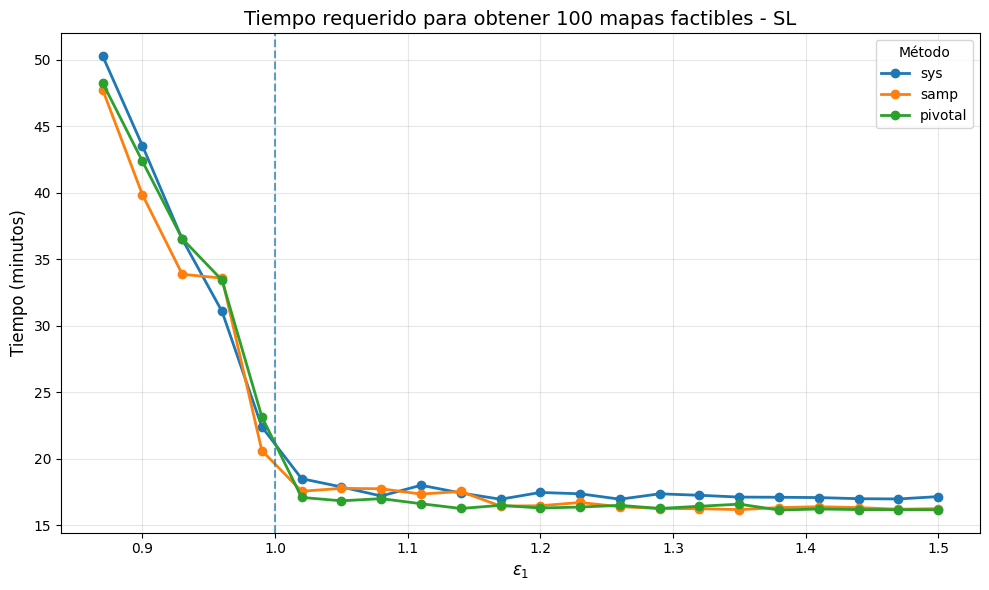

In [23]:
# pasar a minutos
df["tiempo_minutos"] = df["tiempo_segundos"] / 60

fig, ax = plt.subplots(figsize=(10,6))

for metodo in ["sys", "samp", "pivotal"]:

    sub = (
        df[df["metodo"] == metodo]
        .sort_values("epsilon_1")
    )

    ax.plot(
        sub["epsilon_1"],
        sub["tiempo_minutos"],
        marker="o",
        linewidth=2,
        label=metodo
    )

ax.axvline(1.0, linestyle="--", alpha=0.7)

ax.set_xlabel(r"$\epsilon_1$", fontsize=12)
ax.set_ylabel("Tiempo (minutos)", fontsize=12)

ax.set_title(
    "Tiempo requerido para obtener 100 mapas factibles - SL",
    fontsize=14
)

ax.grid(alpha=0.3)
ax.legend(title="Método")

plt.tight_layout()
plt.show()

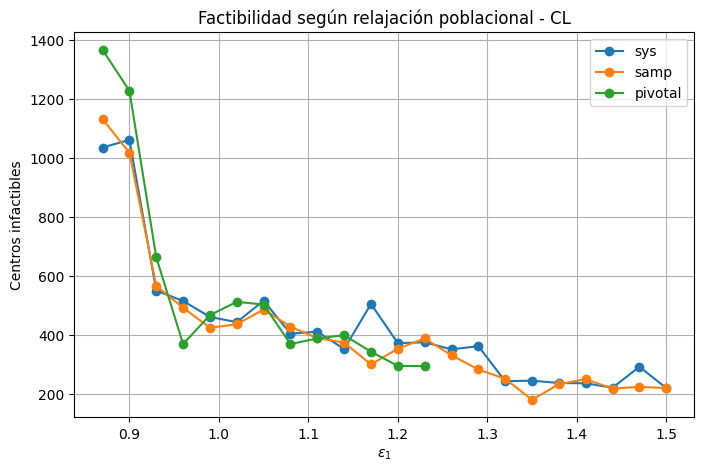

In [6]:


df = pd.read_csv(
    r"resumen_barrido_epsilon_CL.csv"
)

plt.figure(figsize=(8,5))

for metodo in df["metodo"].unique():
    sub = df[df["metodo"] == metodo]

    plt.plot(
        sub["epsilon_1"],
        sub["centros_infactibles"],
        marker="o",
        label=metodo
    )

plt.xlabel(r"$\epsilon_1$")
plt.ylabel("Centros infactibles")
plt.title("Factibilidad según relajación poblacional - CL")
plt.legend()
plt.grid(True)

plt.show()

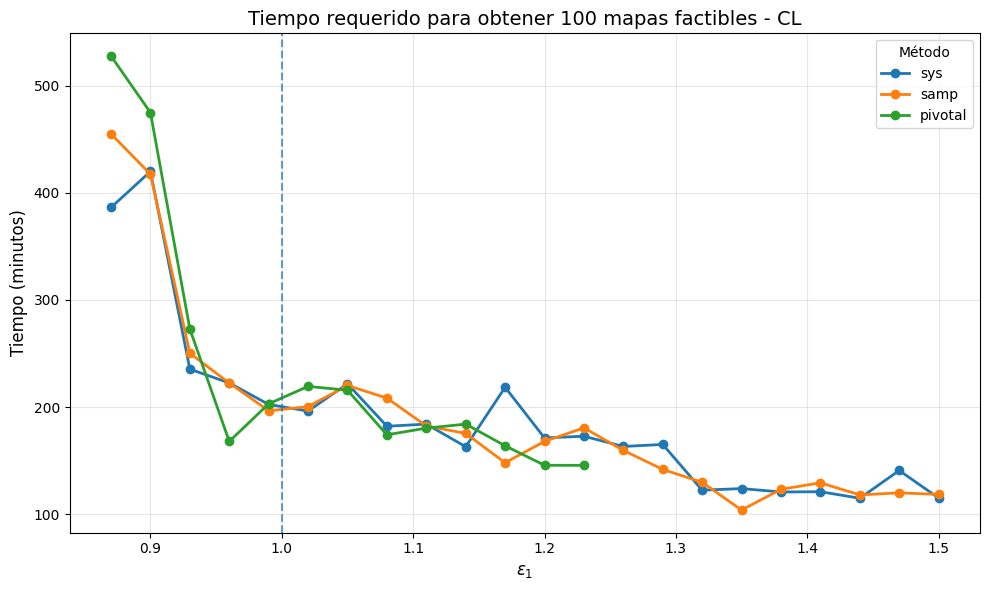

In [7]:
# pasar a minutos
df["tiempo_minutos"] = df["tiempo_segundos"] / 60

fig, ax = plt.subplots(figsize=(10,6))

for metodo in ["sys", "samp", "pivotal"]:

    sub = (
        df[df["metodo"] == metodo]
        .sort_values("epsilon_1")
    )

    ax.plot(
        sub["epsilon_1"],
        sub["tiempo_minutos"],
        marker="o",
        linewidth=2,
        label=metodo
    )

ax.axvline(1.0, linestyle="--", alpha=0.7)

ax.set_xlabel(r"$\epsilon_1$", fontsize=12)
ax.set_ylabel("Tiempo (minutos)", fontsize=12)

ax.set_title(
    "Tiempo requerido para obtener 100 mapas factibles - CL",
    fontsize=14
)

ax.grid(alpha=0.3)
ax.legend(title="Método")

plt.tight_layout()
plt.show()

---

In [3]:
import pandas as pd
import numpy as np
import unicodedata
from DataChile.distritos_chile_actual import DISTRITOS_CHILE


In [9]:

ruta_comunas = r"C:\Tesis\Códigos\DataChile\comunas.xlsx"

comunas_df = pd.read_excel(ruta_comunas)

def normalizar(s):
    s = str(s).lower().strip()
    s = unicodedata.normalize("NFD", s)
    s = "".join(c for c in s if unicodedata.category(c) != "Mn")
    return s

comunas_df["comuna_norm"] = comunas_df["comuna"].apply(normalizar)

# Ajustes por nombres del diccionario actual
correcciones = {
    "casa blanca": "casablanca",
    "la calera": "calera",
    "anguol": "angol",
    "los saucces": "los sauces",

    # nuevos faltantes
    "paihuano": "paiguano",
    "natales": "puerto natales",
}
poblacion = dict(zip(comunas_df["comuna_norm"], comunas_df["poblacion2017"]))

In [10]:
filas = []

for distrito, comunas in DISTRITOS_CHILE.items():
    for comuna in comunas:
        comuna_norm = normalizar(comuna)
        comuna_norm = correcciones.get(comuna_norm, comuna_norm)

        filas.append({
            "distrito": distrito,
            "comuna": comuna,
            "comuna_norm": comuna_norm,
            "poblacion": poblacion.get(comuna_norm, np.nan)
        })

df_actual = pd.DataFrame(filas)

In [3]:
faltantes = df_actual[df_actual["poblacion"].isna()]

display(faltantes[["distrito", "comuna", "comuna_norm"]])
print("Cantidad faltantes:", len(faltantes))

,distrito,comuna,comuna_norm
52,6,llaillay,llaillay
153,16,marchihue,marchihue
216,19,treguaco,treguaco
229,21,alto biobio,alto biobio


Cantidad faltantes: 4


In [4]:
pob_distritos_actual = (
    df_actual
    .groupby("distrito")["poblacion"]
    .sum()
    .reset_index(name="poblacion_distrito")
)

display(pob_distritos_actual)

,distrito,poblacion_distrito
0,1,226068.000
1,2,330558.000
2,3,607534.000
3,4,286168.000
4,5,757586.000
5,6,914640.000
6,7,868901.750
7,8,1457786.000
8,9,969806.000
9,10,1082408.000


In [5]:
valores = pob_distritos_actual["poblacion_distrito"]

metricas_actual = pd.DataFrame([{
    "mapa": "Chile_actual",
    "pop_distrito_mean": valores.mean(),
    "pop_distrito_std": valores.std(),
    "pop_distrito_min": valores.min(),
    "pop_distrito_max": valores.max(),
    "pop_distrito_rango": valores.max() - valores.min(),
    "pop_distrito_cv": valores.std() / valores.mean(),
    "pop_distrito_mediana": valores.median()
}])

display(metricas_actual)

,mapa,pop_distrito_mean,pop_distrito_std,pop_distrito_min,pop_distrito_max,pop_distrito_rango,pop_distrito_cv,pop_distrito_mediana
0,Chile_actual,624133.982643,334617.706143,101316.843,1457786.0,1356469.157,0.536131,603146.5


In [6]:
duplicadas = (
    df_actual.groupby("comuna_norm")["distrito"]
    .apply(list)
    .reset_index()
)

duplicadas = duplicadas[duplicadas["distrito"].apply(len) > 1]

display(duplicadas)

,comuna_norm,distrito


---

In [29]:
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import normalized_mutual_info_score

# =========================================================
# LABELS MAPA ACTUAL
# =========================================================
import unicodedata

import unicodedata

def normalizar_comuna(s):
    s = str(s).lower().strip()
    s = unicodedata.normalize("NFD", s)
    s = "".join(c for c in s if unicodedata.category(c) != "Mn")
    s = s.replace(" ", "")
    return s

correcciones_actual = {
    "casablanca": "casablanca",
    "casablanca": "casablanca",
    "lacalera": "calera",
    "anguol": "angol",
    "lossaucces": "lossauces",
    "paihuano": "paiguano",
    "natales": "puertonatales",
    "llayllay": "llaillay",
    "marchihue": "marchigue",
    "treguaco": "trehuaco"
}
def normalizar_comuna(s):

    s = s.lower().strip()

    s = unicodedata.normalize("NFD", s)

    s = "".join(
        c for c in s
        if unicodedata.category(c) != "Mn"
    )

    s = s.replace(" ", "")

    return s

def labels_mapa_actual(DISTRITOS_CHILE, comunas_modelo):

    asignacion_actual = {}

    for distrito, lista_comunas in DISTRITOS_CHILE.items():
        for c in lista_comunas:
            c_norm = normalizar_comuna(c)
            c_norm = correcciones_actual.get(c_norm, c_norm)
            asignacion_actual[c_norm] = distrito

    labels = []
    comunas_usadas = []
    faltantes = []

    for c in comunas_modelo:
        c_norm = normalizar_comuna(c)
        c_norm = correcciones_actual.get(c_norm, c_norm)

        if c_norm not in asignacion_actual:
            faltantes.append(c)
            continue

        labels.append(asignacion_actual[c_norm])
        comunas_usadas.append(c)

    return labels, comunas_usadas, faltantes

In [30]:
mapas_cl, comunas_cl, asignaciones_cl = cargar_labels_desde_resultados(
    ruta_resultados,
    tipo_filtrar="CL"
)

mapas_sl, comunas_sl, asignaciones_sl = cargar_labels_desde_resultados(
    ruta_resultados,
    tipo_filtrar="SL"
)

In [47]:
mapas = {**mapas_cl, **mapas_sl}
comunas = comunas_cl  # si comunas_cl == comunas_sl

In [48]:
labels_actual, comunas_actual, faltantes = labels_mapa_actual(
    DISTRITOS_CHILE,
    comunas
)

print("faltantes:", faltantes)

faltantes: []


In [49]:
# índices de comunas válidas
idx_validos = [i for i, c in enumerate(comunas) if c in comunas_actual]

resultados_actual = []

for nombre_mapa, labels_mapa in mapas.items():

    labels_filtrado = [labels_mapa[i] for i in idx_validos]

    ari = adjusted_rand_score(labels_actual, labels_filtrado)

    nmi = normalized_mutual_info_score(
        labels_actual,
        labels_filtrado,
        average_method="arithmetic"
    )

    resultados_actual.append({
        "mapa": nombre_mapa,
        "ARI_vs_actual": ari,
        "NMI_vs_actual": nmi
    })

df_actual_comp = pd.DataFrame(resultados_actual)

display(df_actual_comp.sort_values("ARI_vs_actual", ascending=False).head(10))

,mapa,ARI_vs_actual,NMI_vs_actual
169,resultados_CL_SYS_epsilon_0.87_t_070,0.759851,0.898067
292,resultados_CL_samp_epsilon_0.87_t_093,0.745840,0.895446
80,resultados_CL_PIVOTAL_epsilon_0.87_t_081,0.745016,0.895198
61,resultados_CL_PIVOTAL_epsilon_0.87_t_062,0.739946,0.888701
59,resultados_CL_PIVOTAL_epsilon_0.87_t_060,0.736481,0.892163
178,resultados_CL_SYS_epsilon_0.87_t_079,0.736210,0.886928
77,resultados_CL_PIVOTAL_epsilon_0.87_t_078,0.735082,0.893489
177,resultados_CL_SYS_epsilon_0.87_t_078,0.732670,0.881242
290,resultados_CL_samp_epsilon_0.87_t_091,0.731162,0.888080
262,resultados_CL_samp_epsilon_0.87_t_063,0.730116,0.885491


In [50]:
def detectar_metodo(nombre):

    n = nombre.lower()

    if "sys" in n:
        return "sys"

    if "piv" in n:
        return "pivotal"

    if "samp" in n:
        return "sampford"

    return "otro"


def detectar_tipo(nombre):

    n = nombre.lower()

    if "_cl_" in n:
        return "CL"

    if "_sl_" in n:
        return "SL"

    return "otro"


df_actual_comp["metodo"] = df_actual_comp["mapa"].apply(detectar_metodo)

df_actual_comp["tipo"] = df_actual_comp["mapa"].apply(detectar_tipo)

In [51]:
# =========================================================
# RESUMEN ESTADÍSTICO
# =========================================================

resumen_actual = (
    df_actual_comp[["ARI_vs_actual", "NMI_vs_actual"]]
    .agg(["mean", "std", "min", "median", "max"])
    .T
    .reset_index()
    .rename(columns={"index": "metrica"})
)

display(resumen_actual)

,metrica,mean,std,min,median,max
0,ARI_vs_actual,0.510304,0.173948,0.227891,0.531761,0.759851
1,NMI_vs_actual,0.786320,0.087645,0.644851,0.803645,0.898067


In [52]:
# =========================================================
# DETECTAR MÉTODO
# =========================================================

def detectar_metodo(nombre):

    n = nombre.lower()

    if "sys" in n:
        return "sys"

    if "piv" in n:
        return "pivotal"

    if "samp" in n:
        return "sampford"

    return "otro"

df_actual_comp["metodo"] = df_actual_comp["mapa"].apply(detectar_metodo)

In [53]:
# =========================================================
# RESUMEN POR MÉTODO
# =========================================================

tabla_actual_metodo = (
    df_actual_comp
    .groupby("metodo")[["ARI_vs_actual", "NMI_vs_actual"]]
    .agg(["mean", "std", "min", "median", "max"])
)

display(tabla_actual_metodo)

ARI_vs_actual                                         NMI_vs_actual  \
                  mean       std       min    median       max          mean   
metodo                                                                         
pivotal       0.510227  0.177407  0.227891  0.531761  0.745016      0.785751   
sampford      0.508418  0.171528  0.269556  0.528059  0.745840      0.785809   
sys           0.512267  0.173709  0.267680  0.528277  0.759851      0.787400   

                                                  
               std       min    median       max  
metodo                                            
pivotal   0.089197  0.644851  0.805113  0.895198  
sampford  0.086751  0.653790  0.793191  0.895446  
sys       0.087398  0.658628  0.800282  0.898067

In [54]:
display(
    df_actual_comp
    .sort_values("ARI_vs_actual", ascending=False)
    .head(10)
)

,mapa,ARI_vs_actual,NMI_vs_actual,metodo,tipo
169,resultados_CL_SYS_epsilon_0.87_t_070,0.759851,0.898067,sys,CL
292,resultados_CL_samp_epsilon_0.87_t_093,0.745840,0.895446,sampford,CL
80,resultados_CL_PIVOTAL_epsilon_0.87_t_081,0.745016,0.895198,pivotal,CL
61,resultados_CL_PIVOTAL_epsilon_0.87_t_062,0.739946,0.888701,pivotal,CL
59,resultados_CL_PIVOTAL_epsilon_0.87_t_060,0.736481,0.892163,pivotal,CL
178,resultados_CL_SYS_epsilon_0.87_t_079,0.736210,0.886928,sys,CL
77,resultados_CL_PIVOTAL_epsilon_0.87_t_078,0.735082,0.893489,pivotal,CL
177,resultados_CL_SYS_epsilon_0.87_t_078,0.732670,0.881242,sys,CL
290,resultados_CL_samp_epsilon_0.87_t_091,0.731162,0.888080,sampford,CL
262,resultados_CL_samp_epsilon_0.87_t_063,0.730116,0.885491,sampford,CL


In [55]:
display(
    df_actual_comp
    .sort_values("ARI_vs_actual", ascending=True)
    .head(10)
)

,mapa,ARI_vs_actual,NMI_vs_actual,metodo,tipo
392,resultados_SL_piv_epsilon_0.87_t_093,0.227891,0.644851,pivotal,SL
331,resultados_SL_piv_epsilon_0.87_t_032,0.252171,0.648289,pivotal,SL
310,resultados_SL_piv_epsilon_0.87_t_011,0.262859,0.664292,pivotal,SL
586,resultados_SL_sys_epsilon_0.87_t_087,0.267680,0.658628,sys,SL
342,resultados_SL_piv_epsilon_0.87_t_043,0.269136,0.663053,pivotal,SL
423,resultados_SL_samp_epsilon_0.87_t_024,0.269556,0.662348,sampford,SL
509,resultados_SL_sys_epsilon_0.87_t_010,0.270360,0.659728,sys,SL
545,resultados_SL_sys_epsilon_0.87_t_046,0.273844,0.663749,sys,SL
436,resultados_SL_samp_epsilon_0.87_t_037,0.275790,0.653790,sampford,SL
550,resultados_SL_sys_epsilon_0.87_t_051,0.275891,0.666920,sys,SL


In [56]:
tabla_actual = (
    df_actual_comp
    .groupby(["tipo", "metodo"])[["ARI_vs_actual", "NMI_vs_actual"]]
    .agg(["mean", "std", "min", "median", "max"])
)

display(tabla_actual)

ARI_vs_actual                                          \
                       mean       std       min    median       max   
tipo metodo                                                           
CL   pivotal       0.683893  0.025922  0.625630  0.682032  0.745016   
     sampford      0.677179  0.022521  0.633926  0.677795  0.745840   
     sys           0.683037  0.025507  0.628427  0.683532  0.759851   
SL   pivotal       0.336560  0.040781  0.227891  0.333456  0.437893   
     sampford      0.339657  0.033130  0.269556  0.337971  0.422191   
     sys           0.341496  0.033013  0.267680  0.342034  0.428127   

              NMI_vs_actual                                          
                       mean       std       min    median       max  
tipo metodo                                                          
CL   pivotal       0.873034  0.009858  0.851956  0.871768  0.895198  
     sampford      0.871081  0.008820  0.849022  0.871280  0.895446  
     sys           0.873424  0.009270  0.852463  0.873114  0.898067  
SL   pivotal       0.698467  0.022469  0.644851  0.697599  0.758269  
     sampford      0.700538  0.018978  0.653790  0.701643  0.737360  
     sys           0.701376  0.017844  0.658628  0.701779  0.748100

In [7]:
# =========================================================
# ASIGNACIÓN COMUNA -> DISTRITO
# =========================================================

import unicodedata

def normalizar_comuna(s):
    s = str(s).lower().strip()

    s = unicodedata.normalize("NFD", s)

    s = "".join(
        c for c in s
        if unicodedata.category(c) != "Mn"
    )

    return s

asignacion_actual = {}

for distrito, lista_comunas in DISTRITOS_CHILE.items():

    for c in lista_comunas:

        c_norm = normalizar_comuna(c)

        asignacion_actual[c_norm] = distrito


# =========================================================
# MÉTRICA
# =========================================================

conteo = 0

for comuna, distrito in asignacion_actual.items():

    vecinos = dict_ady.get(comuna, [])

    for v in vecinos:

        v_norm = normalizar_comuna(v)

        if v_norm in asignacion_actual:

            if asignacion_actual[v_norm] != distrito:

                conteo += 1


print("Adyacencia externa mapa actual:", conteo)

Adyacencia externa mapa actual: 427
